<h2>Advanced Data Visualization Techniques</h2>

In [2]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [4]:
newsgroups = fetch_20newsgroups(subset='train', categories=['sci.space'])

In [5]:
texts = newsgroups.data[:100]

In [6]:
texts

["From: henry@zoo.toronto.edu (Henry Spencer)\nSubject: Re: japanese moon landing?\nOrganization: U of Toronto Zoology\nLines: 21\n\nIn article <1qnb9tINN7ff@rave.larc.nasa.gov> C.O.EGALON@LARC.NASA.GOV (CLAUDIO OLIVEIRA EGALON) writes:\n>> there is no such thing as a stable lunar orbit\n>\n>Is it right??? That is new stuff for me. So it means that  you just can \n>not put a sattellite around around the Moon for too long because its \n>orbit will be unstable??? If so, what is the reason??? Is that because \n>the combined gravitacional atraction of the Sun,Moon and Earth \n>that does not provide a stable  orbit around the Moon???\n\nAny lunar satellite needs fuel to do regular orbit corrections, and when\nits fuel runs out it will crash within months.  The orbits of the Apollo\nmotherships changed noticeably during lunar missions lasting only a few\ndays.  It is *possible* that there are stable orbits here and there --\nthe Moon's gravitational field is poorly mapped -- but we know of n

In [9]:
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
x = vectorizer.fit_transform(texts)

In [10]:
print(x)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6546 stored elements and shape (100, 1000)>
  Coords	Values
  (0, 423)	5
  (0, 998)	2
  (0, 917)	4
  (0, 313)	2
  (0, 844)	2
  (0, 870)	1
  (0, 596)	7
  (0, 501)	1
  (0, 652)	1
  (0, 999)	2
  (0, 525)	1
  (0, 30)	1
  (0, 120)	1
  (0, 606)	2
  (0, 401)	2
  (0, 993)	1
  (0, 895)	1
  (0, 543)	3
  (0, 646)	4
  (0, 767)	1
  (0, 618)	1
  (0, 868)	1
  (0, 568)	1
  (0, 487)	1
  (0, 534)	1
  :	:
  (99, 77)	3
  (99, 291)	2
  (99, 213)	1
  (99, 663)	2
  (99, 264)	1
  (99, 953)	1
  (99, 624)	1
  (99, 692)	1
  (99, 431)	1
  (99, 619)	1
  (99, 432)	1
  (99, 339)	1
  (99, 19)	1
  (99, 520)	1
  (99, 977)	1
  (99, 615)	1
  (99, 151)	1
  (99, 533)	1
  (99, 222)	1
  (99, 345)	1
  (99, 642)	1
  (99, 952)	1
  (99, 152)	1
  (99, 964)	1
  (99, 905)	1


In [11]:
word_freq = dict(zip(vectorizer.get_feature_names_out(), x.toarray().sum(axis=0)))

In [12]:
word_freq

{'00': np.int64(6),
 '000': np.int64(21),
 '01': np.int64(12),
 '02': np.int64(6),
 '04': np.int64(12),
 '05': np.int64(6),
 '06': np.int64(5),
 '07': np.int64(6),
 '08': np.int64(8),
 '10': np.int64(38),
 '100': np.int64(5),
 '11': np.int64(13),
 '111': np.int64(4),
 '12': np.int64(24),
 '13': np.int64(9),
 '14': np.int64(13),
 '15': np.int64(36),
 '16': np.int64(7),
 '17': np.int64(7),
 '18': np.int64(8),
 '19': np.int64(10),
 '1984': np.int64(6),
 '1985': np.int64(5),
 '1987': np.int64(5),
 '1988': np.int64(9),
 '1993': np.int64(27),
 '1993apr20': np.int64(6),
 '1993apr21': np.int64(6),
 '20': np.int64(25),
 '205': np.int64(4),
 '21': np.int64(10),
 '22': np.int64(12),
 '2238': np.int64(7),
 '23': np.int64(11),
 '24': np.int64(6),
 '25': np.int64(14),
 '264': np.int64(4),
 '27': np.int64(5),
 '28': np.int64(7),
 '282': np.int64(5),
 '29': np.int64(4),
 '30': np.int64(12),
 '300': np.int64(4),
 '31': np.int64(8),
 '32': np.int64(5),
 '34': np.int64(4),
 '35': np.int64(5),
 '3539': np

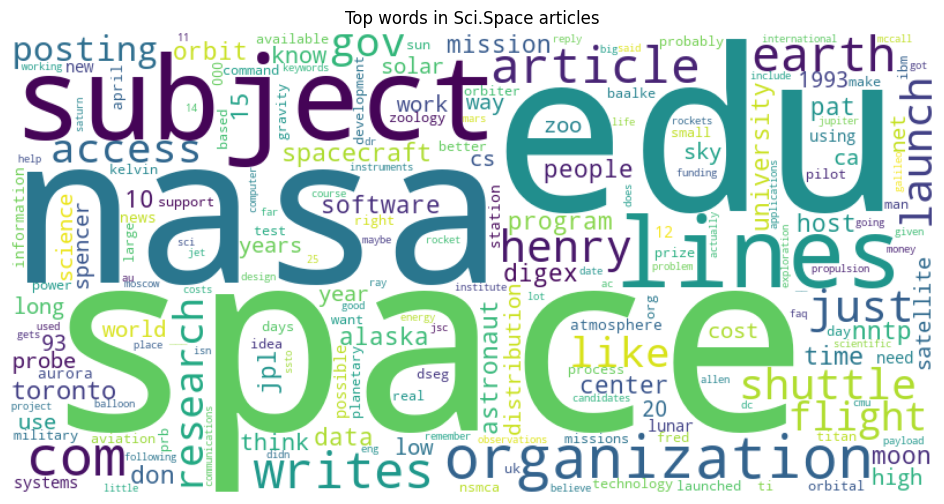

In [14]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='hamming')
plt.axis('off')
plt.title('Top words in Sci.Space articles')
plt.show()